# AdaBoost Implementation (Boosting) - An Ensemble Technique

## 1.Problem Statement

Trip🧳and Travel🧭Company need viable business model to expand customer base.

"Trips & Travel.Com" company wants to enable and establish a viable business model to expand the customer base. One of the ways to expand the customer base is to introduce a new offering of packages. Currently, there are 5 types of packages the company is offering - Basic, Standard, Deluxe, Super Deluxe, King. Looking at the data of the last year, we observed that 18% of the customers purchased the packages. However, the marketing cost was quite high because customers were contacted at random without looking at the available information. The company is now planning to launch a new product i.e. Wellness Tourism Package. Wellness Tourism is defined as Travel that allows the traveler to maintain, enhance or kick-start a healthy lifestyle, and support or increase one's sense of well-being. However, this time company wants to harness the available data of existing and potential customers to make the marketing expenditure more efficient.



## 2.Data Collection

The dataset is taken from https://www.kaggle.com/datasets/susant4learning/holiday-package-purchase-prediction .

## 3.Importing required libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

## 4.Reading data

In [2]:
df=pd.read_csv(f'Travel.csv')
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


## 5.Data Cleaning

### Handling Missing values

In [3]:
df.shape

(4888, 20)

In [4]:
df.isnull().sum()

CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                4888 non-null   int64  
 1   ProdTaken                 4888 non-null   int64  
 2   Age                       4662 non-null   float64
 3   TypeofContact             4863 non-null   object 
 4   CityTier                  4888 non-null   int64  
 5   DurationOfPitch           4637 non-null   float64
 6   Occupation                4888 non-null   object 
 7   Gender                    4888 non-null   object 
 8   NumberOfPersonVisiting    4888 non-null   int64  
 9   NumberOfFollowups         4843 non-null   float64
 10  ProductPitched            4888 non-null   object 
 11  PreferredPropertyStar     4862 non-null   float64
 12  MaritalStatus             4888 non-null   object 
 13  NumberOfTrips             4748 non-null   float64
 14  Passport

In [6]:
categorical_columns=['ProdTaken','TypeofContact','CityTier','Occupation','Gender','ProductPitched','MaritalStatus','Passport','OwnCar','Designation']

for column in categorical_columns:
    print(column)
    print(df[column].value_counts())
    print()

ProdTaken
0    3968
1     920
Name: ProdTaken, dtype: int64

TypeofContact
Self Enquiry       3444
Company Invited    1419
Name: TypeofContact, dtype: int64

CityTier
1    3190
3    1500
2     198
Name: CityTier, dtype: int64

Occupation
Salaried          2368
Small Business    2084
Large Business     434
Free Lancer          2
Name: Occupation, dtype: int64

Gender
Male       2916
Female     1817
Fe Male     155
Name: Gender, dtype: int64

ProductPitched
Basic           1842
Deluxe          1732
Standard         742
Super Deluxe     342
King             230
Name: ProductPitched, dtype: int64

MaritalStatus
Married      2340
Divorced      950
Single        916
Unmarried     682
Name: MaritalStatus, dtype: int64

Passport
0    3466
1    1422
Name: Passport, dtype: int64

OwnCar
1    3032
0    1856
Name: OwnCar, dtype: int64

Designation
Executive         1842
Manager           1732
Senior Manager     742
AVP                342
VP                 230
Name: Designation, dtype: int64



In [7]:
df['Gender']=df['Gender'].replace('Fe Male','Female')
df['MaritalStatus']=df['MaritalStatus'].replace('Single','Unmarried')

In [8]:
print(df['Gender'].value_counts())
print()
print(df['MaritalStatus'].value_counts())

Male      2916
Female    1972
Name: Gender, dtype: int64

Married      2340
Unmarried    1598
Divorced      950
Name: MaritalStatus, dtype: int64


In [9]:
# Checking Missing Values

features_with_na=[feature for feature in df.columns if df[feature].isnull().sum()>=1]

print("% of Missing Values:\n")
for feature in features_with_na:
    print(feature,':',np.round(df[feature].isnull().mean()*100,3),'%')
    

% of Missing Values:

Age : 4.624 %
TypeofContact : 0.511 %
DurationOfPitch : 5.135 %
NumberOfFollowups : 0.921 %
PreferredPropertyStar : 0.532 %
NumberOfTrips : 2.864 %
NumberOfChildrenVisiting : 1.35 %
MonthlyIncome : 4.767 %


### Summary Statistics on Numerical Columns(Null Cols)

In [10]:
df[features_with_na].describe(exclude='object')

,Age,DurationOfPitch,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,NumberOfChildrenVisiting,MonthlyIncome
count,4662.000000,4637.000000,4843.000000,4862.000000,4748.000000,4822.000000,4655.000000
mean,37.622265,15.490835,3.708445,3.581037,3.236521,1.187267,23619.853491
std,9.316387,8.519643,1.002509,0.798009,1.849019,0.857861,5380.698361
min,18.000000,5.000000,1.000000,3.000000,1.000000,0.000000,1000.000000
25%,31.000000,9.000000,3.000000,3.000000,2.000000,1.000000,20346.000000
50%,36.000000,13.000000,4.000000,3.000000,3.000000,1.000000,22347.000000
75%,44.000000,20.000000,4.000000,4.000000,4.000000,2.000000,25571.000000
max,61.000000,127.000000,6.000000,5.000000,22.000000,3.000000,98678.000000


### Imputing Null Values

In [11]:
df['Age'].fillna(df['Age'].median(),inplace=True)
df['TypeofContact'].fillna(df['TypeofContact'].mode()[0],inplace=True)
df['DurationOfPitch'].fillna(df['DurationOfPitch'].median(),inplace=True)
df['NumberOfFollowups'].fillna(df['NumberOfFollowups'].mode()[0],inplace=True)
df['PreferredPropertyStar'].fillna(df['PreferredPropertyStar'].mode()[0],inplace=True)
df['NumberOfTrips'].fillna(0,inplace=True)
df['NumberOfChildrenVisiting'].fillna(df['NumberOfChildrenVisiting'].mode()[0],inplace=True)
df['MonthlyIncome'].fillna(df['MonthlyIncome'].median(),inplace=True)

In [12]:
df.isnull().sum()

CustomerID                  0
ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64

### Summary Statistics on Categorical Columns

In [13]:
df.describe(include='object').T

,count,unique,top,freq
TypeofContact,4888,2,Self Enquiry,3469
Occupation,4888,4,Salaried,2368
Gender,4888,2,Male,2916
ProductPitched,4888,5,Basic,1842
MaritalStatus,4888,3,Married,2340
Designation,4888,5,Executive,1842


In [14]:
df.drop(['CustomerID'],axis=1,inplace=True)

## Feature Engineering

In [15]:
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,0.0,Manager,20993.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Unmarried,7.0,1,3,0,0.0,Executive,17090.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


### Feature Extraction

In [16]:
df['TotalVisiting']=df['NumberOfPersonVisiting']+df['NumberOfChildrenVisiting']
df.drop(columns=['NumberOfPersonVisiting', 'NumberOfChildrenVisiting'], axis=1, inplace=True)

In [17]:
# Get all the numeric,categorical,discrete and continuous features

num_features=[feature for feature in df.columns if df[feature].dtype != 'O']
cat_features=[feature for feature in df.columns if df[feature].dtype == 'O']
discrete_features=[feature for feature in num_features if len(df[feature].unique())<=25]
continuous_features=[feature for feature in num_features if feature not in discrete_features]

print('No.of Numerical Features:',len(num_features))
print('No.of Categorical Features:',len(cat_features))
print('No.of Discrete Features:',len(discrete_features))
print('No.of Continuous Features:',len(continuous_features))

No.of Numerical Features: 12
No.of Categorical Features: 6
No.of Discrete Features: 9
No.of Continuous Features: 3


## Train Test Split

In [18]:
from sklearn.model_selection import train_test_split

X=df.drop(['ProdTaken'],axis=1)
y=df['ProdTaken']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [19]:
X_train

,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalVisiting
736,48.0,Self Enquiry,1,10.0,Salaried,Male,4.0,Standard,3.0,Unmarried,1.0,0,5,1,Senior Manager,25999.0,4.0
1615,30.0,Self Enquiry,1,11.0,Large Business,Female,3.0,Basic,5.0,Married,6.0,0,5,0,Executive,18204.0,3.0
336,29.0,Self Enquiry,1,14.0,Salaried,Male,5.0,Basic,5.0,Divorced,2.0,1,3,1,Executive,17119.0,4.0
4526,29.0,Self Enquiry,3,9.0,Small Business,Female,4.0,Deluxe,4.0,Married,3.0,1,3,1,Manager,23457.0,5.0
2665,34.0,Self Enquiry,1,11.0,Small Business,Female,5.0,Basic,4.0,Divorced,8.0,0,4,0,Executive,21300.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4426,28.0,Self Enquiry,1,10.0,Small Business,Male,5.0,Basic,3.0,Unmarried,2.0,0,1,1,Executive,20723.0,5.0
466,41.0,Self Enquiry,3,8.0,Salaried,Female,3.0,Super Deluxe,5.0,Divorced,1.0,0,5,1,AVP,31595.0,4.0
3092,38.0,Company Invited,3,28.0,Small Business,Female,4.0,Basic,3.0,Divorced,7.0,0,2,1,Executive,21651.0,5.0
3772,28.0,Self Enquiry,3,30.0,Small Business,Female,5.0,Deluxe,3.0,Married,3.0,0,1,1,Manager,22218.0,5.0


In [20]:
X.head()

,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalVisiting
0,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,Manager,20993.0,3.0
1,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Unmarried,7.0,1,3,0,Executive,17090.0,3.0
3,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,36.0,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0


In [21]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     4888 non-null   float64
 1   TypeofContact           4888 non-null   object 
 2   CityTier                4888 non-null   int64  
 3   DurationOfPitch         4888 non-null   float64
 4   Occupation              4888 non-null   object 
 5   Gender                  4888 non-null   object 
 6   NumberOfFollowups       4888 non-null   float64
 7   ProductPitched          4888 non-null   object 
 8   PreferredPropertyStar   4888 non-null   float64
 9   MaritalStatus           4888 non-null   object 
 10  NumberOfTrips           4888 non-null   float64
 11  Passport                4888 non-null   int64  
 12  PitchSatisfactionScore  4888 non-null   int64  
 13  OwnCar                  4888 non-null   int64  
 14  Designation             4888 non-null   

In [22]:
y.value_counts()

0    3968
1     920
Name: ProdTaken, dtype: int64

### Applying Column Transformer

1.OneHotEncoder
2.StandardScaler

In [23]:
cat_features=X.select_dtypes(include='object').columns
num_features=X.select_dtypes(exclude='object').columns

from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer=StandardScaler()
oh_transformer=OneHotEncoder()

preprocessor=ColumnTransformer(
    [
        ('OneHotEncoder',oh_transformer,cat_features),
        ('StandardScaler',numeric_transformer,num_features)
    ]

)

In [24]:
preprocessor

ColumnTransformer(transformers=[('OneHotEncoder', OneHotEncoder(),
                                 Index(['TypeofContact', 'Occupation', 'Gender', 'ProductPitched',
       'MaritalStatus', 'Designation'],
      dtype='object')),
                                ('StandardScaler', StandardScaler(),
                                 Index(['Age', 'CityTier', 'DurationOfPitch', 'NumberOfFollowups',
       'PreferredPropertyStar', 'NumberOfTrips', 'Passport',
       'PitchSatisfactionScore', 'OwnCar', 'MonthlyIncome', 'TotalVisiting'],
      dtype='object'))])

In [25]:
X_train=preprocessor.fit_transform(X_train)
X_test=preprocessor.transform(X_test)

## Model Training

In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score,classification_report,ConfusionMatrixDisplay,confusion_matrix,precision_score,recall_score,f1_score,roc_auc_score,roc_curve

In [27]:
models={'Logistic Regression':LogisticRegression(),
        'Decision Tree':DecisionTreeClassifier(),
        'Random Forest':RandomForestClassifier(),
        'Gradient Boost':GradientBoostingClassifier(),
        'AdaBoost':AdaBoostClassifier()
       }

for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(X_train,y_train)
    
    # Preditcions
    y_train_pred=model.predict(X_train)
    y_test_pred=model.predict(X_test)
    
    # Training data performance
    model_train_accuracy=accuracy_score(y_train,y_train_pred)
    model_train_f1=f1_score(y_train,y_train_pred,average='weighted')
    model_train_prediction=precision_score(y_train,y_train_pred)
    model_train_recall=recall_score(y_train,y_train_pred)
    model_train_rocauc_score=roc_auc_score(y_train,y_train_pred)
    
    # Testing data performance
    model_test_accuracy=accuracy_score(y_test,y_test_pred)
    model_test_f1=f1_score(y_test,y_test_pred,average='weighted')
    model_test_prediction=precision_score(y_test,y_test_pred)
    model_test_recall=recall_score(y_test,y_test_pred)
    model_test_rocauc_score=roc_auc_score(y_test,y_test_pred)
    
    print(list(models.keys())[i])
    
    print('Model Performance for Training data')
    print('-Accuracy: {:.4f}'.format(model_train_accuracy))
    print('-F1 score: {:.4f}'.format(model_train_f1))
    print('-Recall: {:.4f}'.format(model_train_recall))
    print('-ROC AUC score:{:.4f}'.format(model_train_rocauc_score))
    
    print('-'*40)
    
    
    print('Model Performance for Testing data')
    print('-Accuracy: {:.4f}'.format(model_test_accuracy))
    print('-F1 score: {:.4f}'.format(model_test_f1))
    print('-Recall: {:.4f}'.format(model_test_recall))
    print('-ROC AUC score:{:.4f}'.format(model_test_rocauc_score))
    
    print('='*40)
    print('\n')


Logistic Regression
Model Performance for Training data
-Accuracy: 0.8451
-F1 score: 0.8188
-Recall: 0.3034
-ROC AUC score:0.6373
----------------------------------------
Model Performance for Testing data
-Accuracy: 0.8425
-F1 score: 0.8187
-Recall: 0.3139
-ROC AUC score:0.6389


Decision Tree
Model Performance for Training data
-Accuracy: 1.0000
-F1 score: 1.0000
-Recall: 1.0000
-ROC AUC score:1.0000
----------------------------------------
Model Performance for Testing data
-Accuracy: 0.8978
-F1 score: 0.8979
-Recall: 0.7299
-ROC AUC score:0.8331


Random Forest
Model Performance for Training data
-Accuracy: 1.0000
-F1 score: 1.0000
-Recall: 1.0000
-ROC AUC score:1.0000
----------------------------------------
Model Performance for Testing data
-Accuracy: 0.9202
-F1 score: 0.9132
-Recall: 0.6095
-ROC AUC score:0.8006


Gradient Boost
Model Performance for Training data
-Accuracy: 0.8936
-F1 score: 0.8820
-Recall: 0.5093
-ROC AUC score:0.7462
----------------------------------------


### Hyperparameter Tuning

In [28]:
rf_params={
    'max_depth':[5,8,15,None,10],
    'max_features':[5,7,'auto',8],
    'min_samples_split':[2,8,14,20],
    'n_estimators':[100,200,500,1000]
}


random_cv_models=[('RF',RandomForestClassifier(),rf_params)]
random_cv_models

[('RF',
  RandomForestClassifier(),
  {'max_depth': [5, 8, 15, None, 10],
   'max_features': [5, 7, 'auto', 8],
   'min_samples_split': [2, 8, 14, 20],
   'n_estimators': [100, 200, 500, 1000]})]

In [29]:
from sklearn.model_selection import RandomizedSearchCV

model_param={}
for name,model,params in random_cv_models:
    random=RandomizedSearchCV(estimator=model,n_iter=100,param_distributions=params,cv=3,verbose=2,n_jobs=-1)
    random.fit(X_train,y_train)
    model_param[name]=random.best_params_

for model_name in model_param:
    print('\n')
    print(f'----------Best Params for---------- {model_name}')
    print(model_param[model_name])

Fitting 3 folds for each of 100 candidates, totalling 300 fits


----------Best Params for---------- RF
{'n_estimators': 200, 'min_samples_split': 2, 'max_features': 8, 'max_depth': None}


### Training data on Random Forest Model(The Best Model)

In [30]:
rf_clf=RandomForestClassifier(n_estimators=200,min_samples_split=2,max_features=8,max_depth=None)

In [31]:
model=rf_clf

model.fit(X_train,y_train)

# Preditcions
y_train_pred=model.predict(X_train)
y_test_pred=model.predict(X_test)

# Training data performance
model_train_accuracy=accuracy_score(y_train,y_train_pred)
model_train_f1=f1_score(y_train,y_train_pred,average='weighted')
model_train_prediction=precision_score(y_train,y_train_pred)
model_train_recall=recall_score(y_train,y_train_pred)
model_train_rocauc_score=roc_auc_score(y_train,y_train_pred)

# Testing data performance
model_test_accuracy=accuracy_score(y_test,y_test_pred)
model_test_f1=f1_score(y_test,y_test_pred,average='weighted')
model_test_prediction=precision_score(y_test,y_test_pred)
model_test_recall=recall_score(y_test,y_test_pred)
model_test_rocauc_score=roc_auc_score(y_test,y_test_pred)

print('Model Performance for Training data')
print('-Accuracy: {:.4f}'.format(model_train_accuracy))
print('-F1 score: {:.4f}'.format(model_train_f1))
print('-Recall: {:.4f}'.format(model_train_recall))
print('-ROC AUC score:{:.4f}'.format(model_train_rocauc_score))

print('-'*40)


print('Model Performance for Testing data')
print('-Accuracy: {:.4f}'.format(model_test_accuracy))
print('-F1 score: {:.4f}'.format(model_test_f1))
print('-Recall: {:.4f}'.format(model_test_recall))
print('-ROC AUC score:{:.4f}'.format(model_test_rocauc_score))

print('='*40)
print('\n')


Model Performance for Training data
-Accuracy: 1.0000
-F1 score: 1.0000
-Recall: 1.0000
-ROC AUC score:1.0000
----------------------------------------
Model Performance for Testing data
-Accuracy: 0.9264
-F1 score: 0.9211
-Recall: 0.6533
-ROC AUC score:0.8212




### Plotting Reciever Operating Characteristic Curve (ROC Curve)

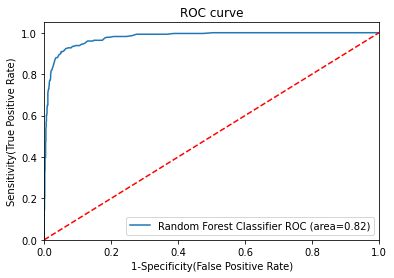

In [32]:
from sklearn.metrics import roc_curve
plt.figure()

fpr,tpr,thresholds=roc_curve(y_test,model.predict_proba(X_test)[:,-1])
plt.plot(fpr,tpr,label='%s ROC (area=%0.2f)' % ('Random Forest Classifier',0.8212))
plt.plot([0,1],[0,1],'r--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('1-Specificity(False Positive Rate)')
plt.ylabel('Sensitivity(True Positive Rate)')
plt.title('ROC curve')
plt.legend(loc='lower right')
plt.show();

### Training data on AdaBoostClassifier Model

In [33]:
model=AdaBoostClassifier()

model.fit(X_train,y_train)

# Preditcions
y_train_pred=model.predict(X_train)
y_test_pred=model.predict(X_test)

# Training data performance
model_train_accuracy=accuracy_score(y_train,y_train_pred)
model_train_f1=f1_score(y_train,y_train_pred,average='weighted')
model_train_prediction=precision_score(y_train,y_train_pred)
model_train_recall=recall_score(y_train,y_train_pred)
model_train_rocauc_score=roc_auc_score(y_train,y_train_pred)

# Testing data performance
model_test_accuracy=accuracy_score(y_test,y_test_pred)
model_test_f1=f1_score(y_test,y_test_pred,average='weighted')
model_test_prediction=precision_score(y_test,y_test_pred)
model_test_recall=recall_score(y_test,y_test_pred)
model_test_rocauc_score=roc_auc_score(y_test,y_test_pred)

print('Model Performance for Training data')
print('-Accuracy: {:.4f}'.format(model_train_accuracy))
print('-F1 score: {:.4f}'.format(model_train_f1))
print('-Recall: {:.4f}'.format(model_train_recall))
print('-ROC AUC score:{:.4f}'.format(model_train_rocauc_score))

print('-'*40)


print('Model Performance for Testing data')
print('-Accuracy: {:.4f}'.format(model_test_accuracy))
print('-F1 score: {:.4f}'.format(model_test_f1))
print('-Recall: {:.4f}'.format(model_test_recall))
print('-ROC AUC score:{:.4f}'.format(model_test_rocauc_score))

print('='*40)
print('\n')


Model Performance for Training data
-Accuracy: 0.8433
-F1 score: 0.8084
-Recall: 0.2430
-ROC AUC score:0.6130
----------------------------------------
Model Performance for Testing data
-Accuracy: 0.8316
-F1 score: 0.7954
-Recall: 0.2153
-ROC AUC score:0.5943




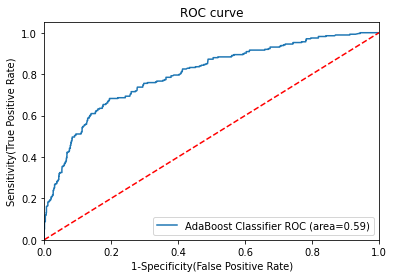

In [36]:
from sklearn.metrics import roc_curve
plt.figure()

fpr,tpr,thresholds=roc_curve(y_test,model.predict_proba(X_test)[:,-1])
plt.plot(fpr,tpr,label='%s ROC (area=%0.2f)' % ('AdaBoost Classifier',0.5943))
plt.plot([0,1],[0,1],'r--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('1-Specificity(False Positive Rate)')
plt.ylabel('Sensitivity(True Positive Rate)')
plt.title('ROC curve')
plt.legend(loc='lower right')
plt.show();